In [17]:
## This version of 1D greedy algorithm, the numerical quadrature used for assembling the linear system is consistent with 
## the quadrature used for the argmax subproblem.
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import math 
import time

import scipy 
from scipy.sparse import linalg
from pathlib import Path
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

pi = torch.tensor(np.pi,dtype=torch.float64)
torch.set_default_dtype(torch.float64)

import sys, os
sys.path.append(os.path.abspath("../../"))
from utils_quad_init import PiecewiseGQ1D_weights_points, PiecewiseGQ2D_weights_points, PiecewiseGQ3D_weights_points, initialize_w_b_uniform, initialize_w_b_sphere, initialize_w_b_petrushev
from utils_quad_init import model_tanh 

In [18]:
def minimize_linear_layer_explicit_assemble(model,target,weights, integration_points,solver="direct",activation = 'tanh'):
    """
    1. assemble matrix and rhs vector 
    2. solve the linear system and return the solution 
    """
    # Nx = 1024
    # order = 5
    # weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx,order) 

    # start_time = time.time()
    w = model.fc1.weight.data
    if activation == 'cos':
        basis_value_col = torch.cos(2*pi* (integration_points @ w.t()) ) # activation function dependent 
    elif activation == 'tanh':
        bias = model.fc1.bias.data 
        basis_value_col = torch.tanh(integration_points @ w.t() + bias) # activation function dependent 
    weighted_basis_value_col = basis_value_col * weights
    jac = weighted_basis_value_col.t() @ basis_value_col 
    # print("assembling the matrix time taken: ", time.time()-start_time) 
    rhs = weighted_basis_value_col.t() @ target(integration_points) 

    # print("using: ",solver, end = " ")
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    return sol 

In [19]:
def plot_err_loglog(neuron_num_arr,mean_err_l2_arr, legend1, title): 

    plt.figure(dpi = 400) 
    plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1) 

    # Taking the logarithm of both M and errors
    log_M = np.log(neuron_num_arr) 
    log_errors = np.log(mean_err_l2_arr)
    # Perform linear regression to find the slope and intercept of the line
    slope, intercept = np.polyfit(log_M, log_errors, 1)
    # Create a function for the line of best fit

    def line_of_best_fit(x):
        return np.exp(intercept) * (x ** slope)
    best_fit = line_of_best_fit(neuron_num_arr) 

    plt.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ))
    plt.yscale('log') 
    plt.xscale('log') 
    plt.legend() 
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title) 
    plt.show() 

In [25]:
def assemble_least_square_linear_system_quadrature(model,rhs, integration_weights,integration_points): 
    """ Assemble the least square linear system, D: design matrix, b right hand side """
    # in_feat, out_feat = model.fc1.weight.shape 
    W = model.fc1.weight.data  # shape: (M, d+1)
    b = model.fc1.bias.data  # shape: (M,)
    Z = integration_points@ W.t() + b  
    D = torch.tanh(Z)  * integration_weights  
    b_rhs = rhs(integration_points) * integration_weights 
    return D,b_rhs


In [26]:
def rescale_mat_rhs(A,f):
    c = 100.0
    for i in range(len(A)):
        ## change 
        max_a = abs(A[i,:]).max()
        max_b = A[i,:].max()
        if max_a != max_b: 
            ratio = -c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
        else: 
            ratio = c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
    return A,f 

## 1D experiment 

In [77]:

def initialize_w_b_petrushev(my_model,R_m,radius = 1, scale = 1):
    w = my_model.fc1.weight
    b = my_model.fc1.bias
    out_feats, in_feats = w.shape
    device = w.device
    n1 = scale * math.ceil(out_feats**((in_feats - 1)/in_feats)) 
    n2 = math.ceil(out_feats**(1/in_feats))
    with torch.no_grad():
        if in_feats == 1:  #n by 1 
            weights = torch.ones(n1,1).to(device)
            # weights[:,0] = torch.linspace(-R_m,R_m,n1) 
        elif in_feats == 2:
            weights = torch.zeros(n1,2).to(device)
            theta = np.linspace(0,pi,n1,endpoint=False) 
            theta = torch.tensor(theta).to(device)
            weights[:, 0] = theta.cos()
            weights[:, 1] = theta.sin() 
            #form a tensor product of weights and biases
        elif in_feats == 3: 
            indices = torch.arange(0, n1, dtype=torch.float) + 0.5
            phi = torch.acos(1 - 2*indices/n1)
            theta = pi * (1 + 5**0.5) * indices
            x = torch.sin(phi) * torch.cos(theta)
            y = torch.sin(phi) * torch.sin(theta)
            z = torch.cos(phi)
            weights = torch.stack((x, y, z), dim=1)
        elif in_feats >= 4: 
            # nn.init.normal_(w, mean = 0, std = 1)
            weights = torch.randn(n1, in_feats).to(device) 
            weights = weights / torch.norm(weights,dim=1).view(-1,1) 

        # form a tensor product of weights and biases 
        weights = torch.tile(weights, (1,n2)).reshape(-1,in_feats) 
        # print("weights shape: ", weights.shape) 
        # print("nn w shape: ", w.shape)
        my_model = model_tanh(in_feats, n1*n2, 1).to(device) 
        biases = torch.linspace(-R_m,R_m,n2).to(device)
        # biases = torch.tensor(biases).to(device) 
        biases = torch.tile(biases, (n1,1)).reshape(-1) 
        # w[:,:] = weights[:out_feats,:] 
        my_model.fc1.weight.data[:,:] = weights[:,:] * radius 
        my_model.fc1.bias.data[:] = biases[:]  

    return my_model 


def initialize_w_b_sphere(my_model,R_m):
    # generate a uniform grid on S^2 
    neuron_nums = my_model.fc1.bias.size(0) 
    out_feats, in_feats = my_model.fc1.weight.shape 
    if in_feats == 2: 
        indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
        phi = torch.acos(1 - 2*indices/neuron_nums)
        theta = pi * (1 + 5**0.5) * indices
        x = torch.sin(phi) * torch.cos(theta)
        y = torch.sin(phi) * torch.sin(theta)
        z = torch.cos(phi)

        points = torch.stack((x, y, z), dim=1)
        my_model.fc1.weight.data[:,:] = points[:,0:2] * R_m
        my_model.fc1.bias.data[:] = points[:,2] * R_m 
    elif in_feats == 1:
        theta = torch.linspace(0, pi, neuron_nums+1)[:-1]
        w1 = torch.cos(theta) * R_m
        b = torch.sin(theta) * R_m
        my_model.fc1.weight.data[:,0] = w1[:]
        my_model.fc1.bias.data[:] = b[:]
    else: 
        w_b = torch.randn(neuron_nums,in_feats + 1) 
        w_b = w_b / torch.norm(w_b,dim=1).view(-1,1) 
        w_b = w_b * R_m 
        my_model.fc1.weight.data[:,:] = w_b[:,:-1] 
        my_model.fc1.bias.data[:] = w_b[:,-1] 
    return my_model 


### Gauss quadrature data points

integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])
integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])
integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])


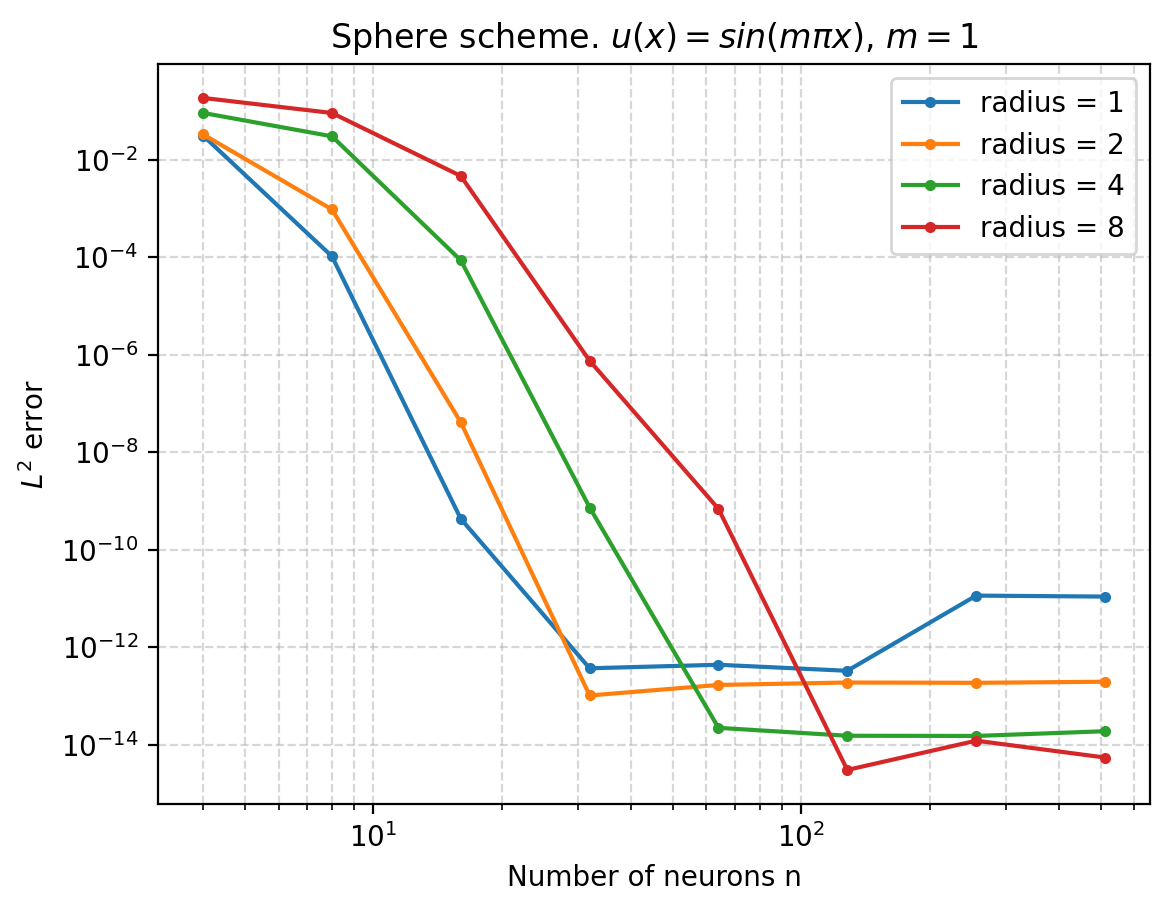

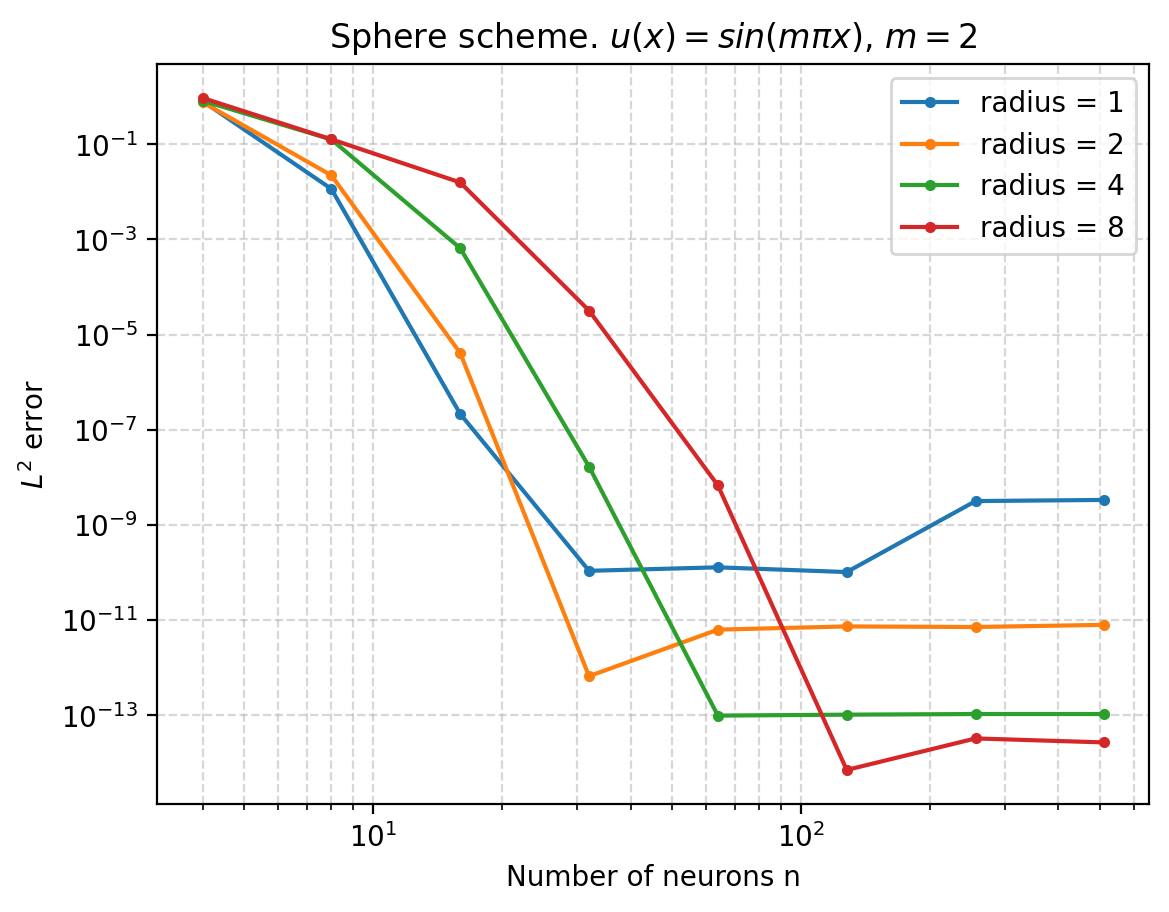

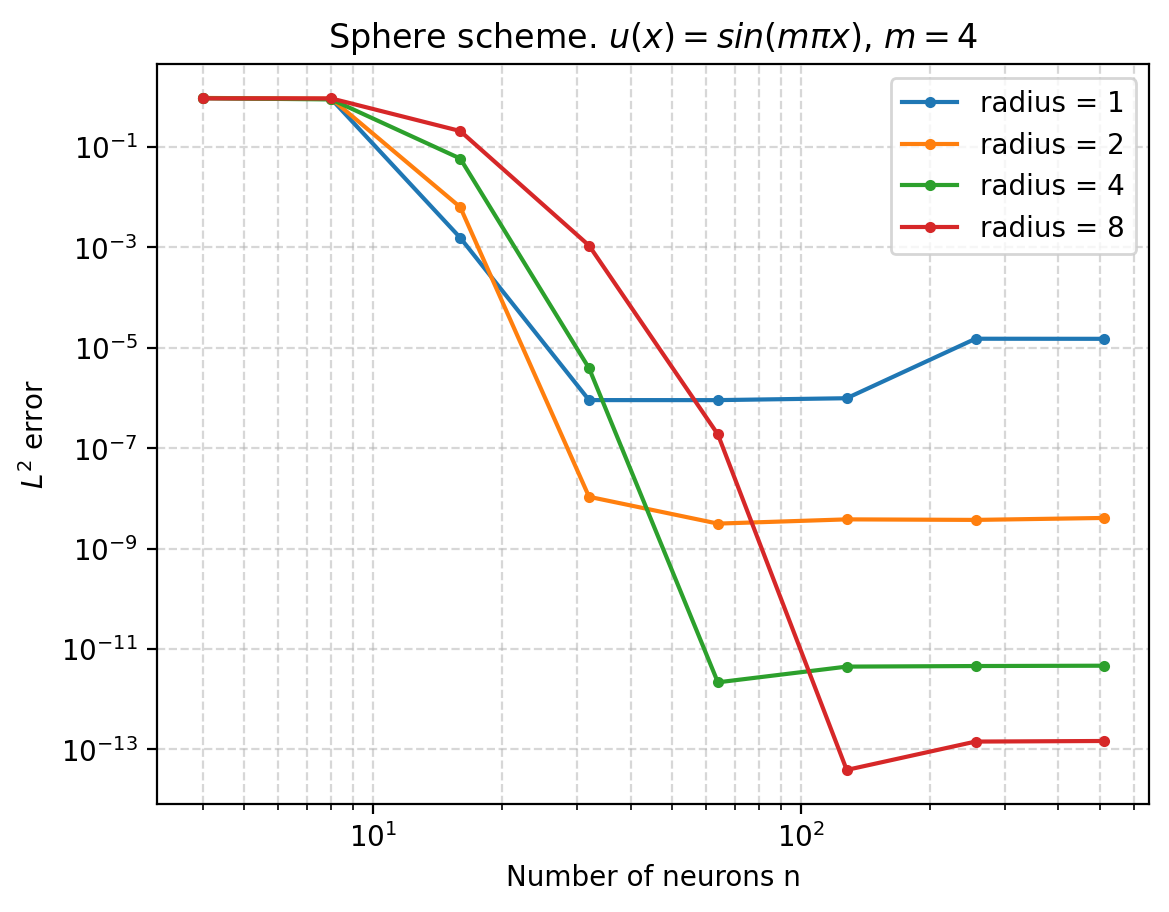

In [88]:

# plt.rcParams.update({'font.size': 10})
from operator import le


def run_exp_petrushev_1d(m): 
    def target(x):
        return torch.sin( m * pi * x)  # + torch.sin(2*m * pi * x) + torch.sin(4*m * pi * x) 
    d =1 
    integration_weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx = 1024, order = 5)
    # integration_weights_test, integration_points_test = PiecewiseGQ1D_weights_points(0,1,Nx = 2048, order = 2)
    print("integration_weights shape: ", integration_weights.shape)
    print("integration_points shape: ", integration_points.shape)  

    # collocation points and weights 
    Q = 1024
    collocation_points = torch.linspace(-1,1,Q).view(-1,1)
    collocation_weights = torch.ones(Q).view(-1,1)
    
    save = True 
    petrushev = False 
    sphere_init = True
    elm = False 
    R_m_list = [1,2,4,8]
    plt.figure(dpi = 200)

    
    for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
        mean_err_l2_list = [] 
        neuron_num_arr= np.array([2**i for i in range(2,10)]) 
        for n in neuron_num_arr : 
            trial_num = 1
            err_l2_trial = torch.zeros(trial_num) 
            for trial in range(trial_num):
                my_model = model_tanh(1, n, 1).to(device) 
                if petrushev: 
                    my_model = initialize_w_b_petrushev(my_model, R_m = R_m, radius = radius)
                if elm: 
                    my_model = initialize_w_b_uniform(my_model, R_m=R_m) 
                if sphere_init: 
                    my_model = initialize_w_b_sphere(my_model,R_m) 
                D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,collocation_weights, collocation_points )
                D, b_rhs = rescale_mat_rhs(D,b_rhs)

                sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
                sol =torch.tensor(sol)
                my_model.fc2.weight.data[0,:] = sol.view(-1) 

                with torch.no_grad(): 
                    nn_func_values = my_model(integration_points) 
                target_values = target(integration_points) 

                diff_sqrd = (nn_func_values - target_values)**2 
                err_l2 = ( integration_weights.t() @ diff_sqrd )**0.5 
                err_l2_trial[trial] = err_l2 
            mean_err_l2 = torch.mean(err_l2_trial) 
            mean_err_l2_list.append(mean_err_l2) 
        mean_err_l2_arr = np.array(mean_err_l2_list) 

        # legend1 =f"$r_1 = {radius}, r_2 = {R_m}$"
        legend1 = f"radius = {R_m}"
        if petrushev: 
            title = f"Petrushev's scheme. $u(x) = sin(m \pi x)$, $m={m}$"
            # title = f"Petrushev. $r_1 = {radius}, r_2 = {R_m}$. $u(x) = sin(m \pi x)$, $m={m}$" 
        if elm: 
            title = f"$(\omega_i,b_i) \sim U([-R,R]^{d+1})$. $u(x) = sin(m \pi x)$, $m={m}$"
        if sphere_init: 
            title = f"Sphere scheme. $u(x) = sin(m \pi x)$, $m={m}$"
        plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
        # plot a reference line and the slope
        plt.yscale('log')
        plt.xscale('log')
        plt.legend()
        plt.ylabel("$L^2$ error")
        plt.xlabel("Number of neurons n")
        plt.title(title)
    
    plt.grid(True, which="both", ls="--", alpha=0.5)
    if petrushev: 
        filename = "data/petrushev_1d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
    if elm: 
        filename = "data/elm_1d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
    if sphere_init: 
        filename = "data/sphere_scheme_1d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
    if save:
        plt.savefig(filename)
    else: 
        plt.show()

for m in [1,2,4]:
    run_exp_petrushev_1d(m)

integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])
radius:  4
integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])
radius:  4
integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])
radius:  4


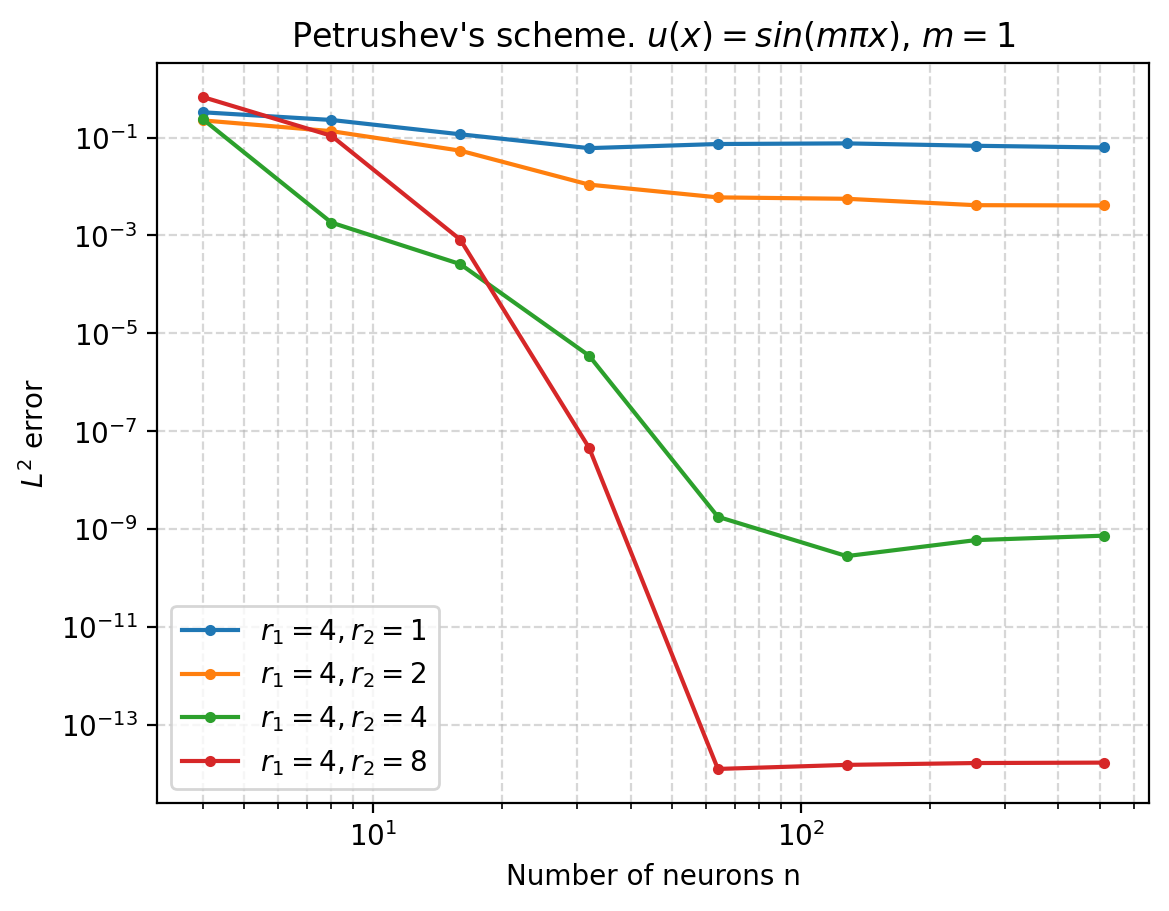

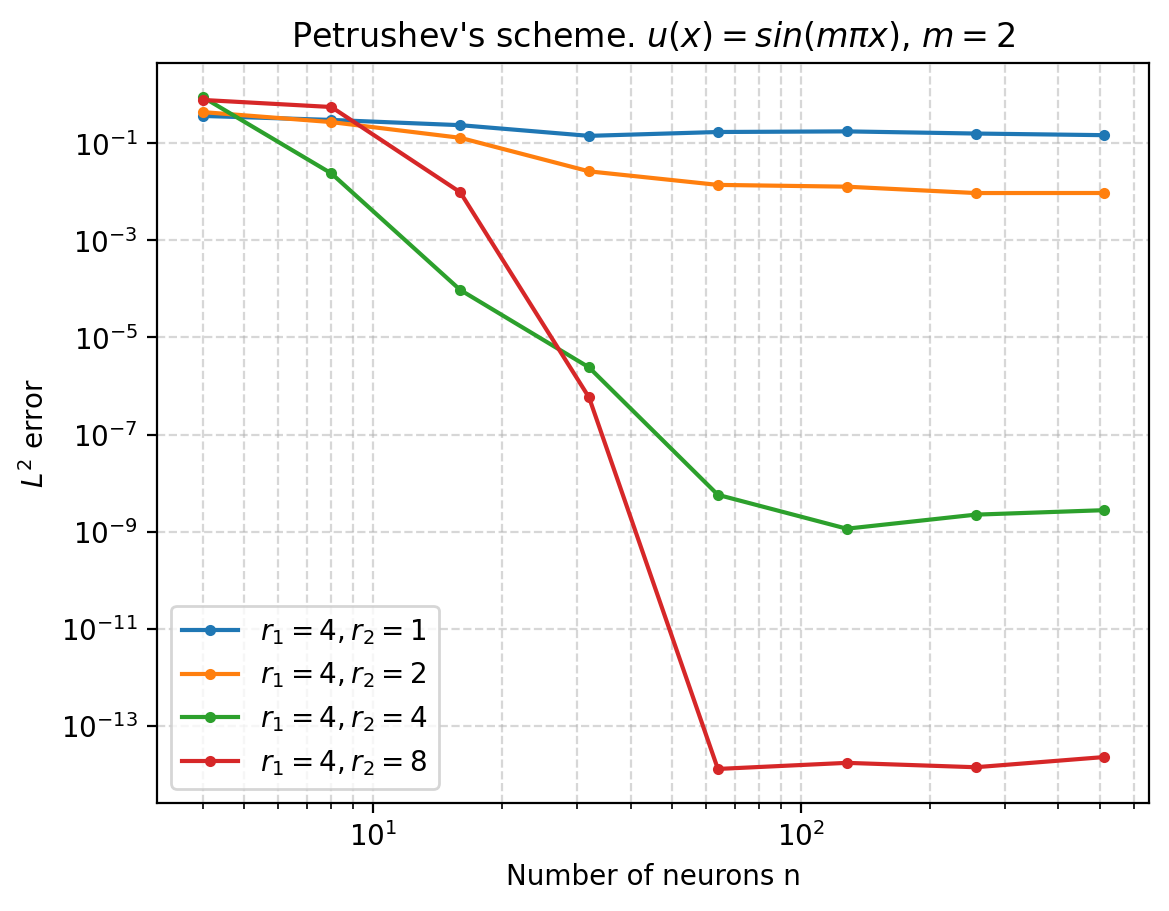

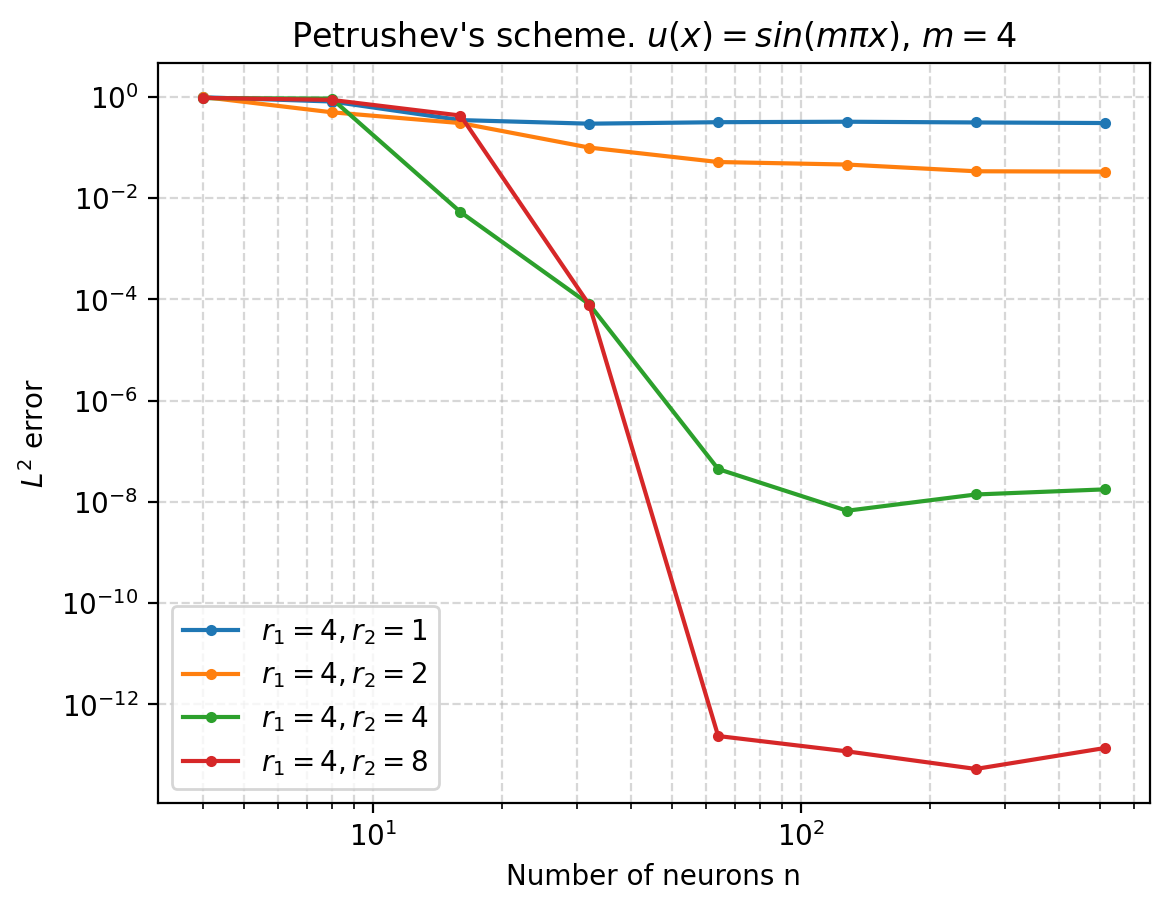

In [75]:

# plt.rcParams.update({'font.size': 10})
def run_exp_petrushev_1d(m): 
    def target(x):
        return torch.sin( m * pi * x)  # + torch.sin(2*m * pi * x) + torch.sin(4*m * pi * x) 
    d =1 
    integration_weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx = 1024, order = 5)
    # integration_weights_test, integration_points_test = PiecewiseGQ1D_weights_points(0,1,Nx = 2048, order = 2)
    print("integration_weights shape: ", integration_weights.shape)
    print("integration_points shape: ", integration_points.shape)  

    # collocation points and weights 
    Q = 1024
    collocation_points = torch.linspace(-1,1,Q).view(-1,1)
    collocation_weights = torch.ones(Q).view(-1,1)
    
    save = True 
    petrushev = True 
    R_m_list = [1,2,4,8]
    plt.figure(dpi = 200)
    for radius in [4]: 
        print("radius: ", radius)  
        
        for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
            mean_err_l2_list = [] 
            neuron_num_arr= np.array([2**i for i in range(2,10)]) 
            for n in neuron_num_arr : 
                trial_num = 1 
                err_l2_trial = torch.zeros(trial_num) 
                for trial in range(trial_num):
                    my_model = model_tanh(1, n, 1).to(device) 
                    if petrushev: 
                        my_model = initialize_w_b_petrushev(my_model, R_m = R_m, radius = radius)
                    else: 
                        my_model = initialize_w_b_uniform(my_model, R_m=R_m) 
                    D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,collocation_weights, collocation_points )
                    D, b_rhs = rescale_mat_rhs(D,b_rhs)

                    sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
                    sol =torch.tensor(sol)
                    my_model.fc2.weight.data[0,:] = sol.view(-1) 

                    with torch.no_grad(): 
                        nn_func_values = my_model(integration_points) 
                    target_values = target(integration_points) 

                    diff_sqrd = (nn_func_values - target_values)**2 
                    err_l2 = ( integration_weights.t() @ diff_sqrd )**0.5 
                    err_l2_trial[trial] = err_l2 
                mean_err_l2 = torch.mean(err_l2_trial) 
                mean_err_l2_list.append(mean_err_l2) 
            mean_err_l2_arr = np.array(mean_err_l2_list) 

            legend1 =f"$r_1 = {radius}, r_2 = {R_m}$"
            if petrushev: 
                title = f"Petrushev's scheme. $u(x) = sin(m \pi x)$, $m={m}$"
                # title = f"Petrushev. $r_1 = {radius}, r_2 = {R_m}$. $u(x) = sin(m \pi x)$, $m={m}$" 
            else: 
                title = f"$(\omega_i,b_i) \sim U([-R,R]^{d+1})$. $u(x) = sin(m \pi x)$, $m={m}$"

            plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
            # plot a reference line and the slope
            plt.yscale('log')
            plt.xscale('log')
            plt.legend()
            plt.ylabel("$L^2$ error")
            plt.xlabel("Number of neurons n")
            plt.title(title)
        
        plt.grid(True, which="both", ls="--", alpha=0.5)
        if petrushev: 
            filename = "data/petrushev_1d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
        else: 
            filename = "data/elm_1d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
        if save:
            plt.savefig(filename)
        else: 
            plt.show()

for m in [1,2,4]:
    run_exp_petrushev_1d(m)

integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])
integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])
integration_weights shape:  torch.Size([5120, 1])
integration_points shape:  torch.Size([5120, 1])


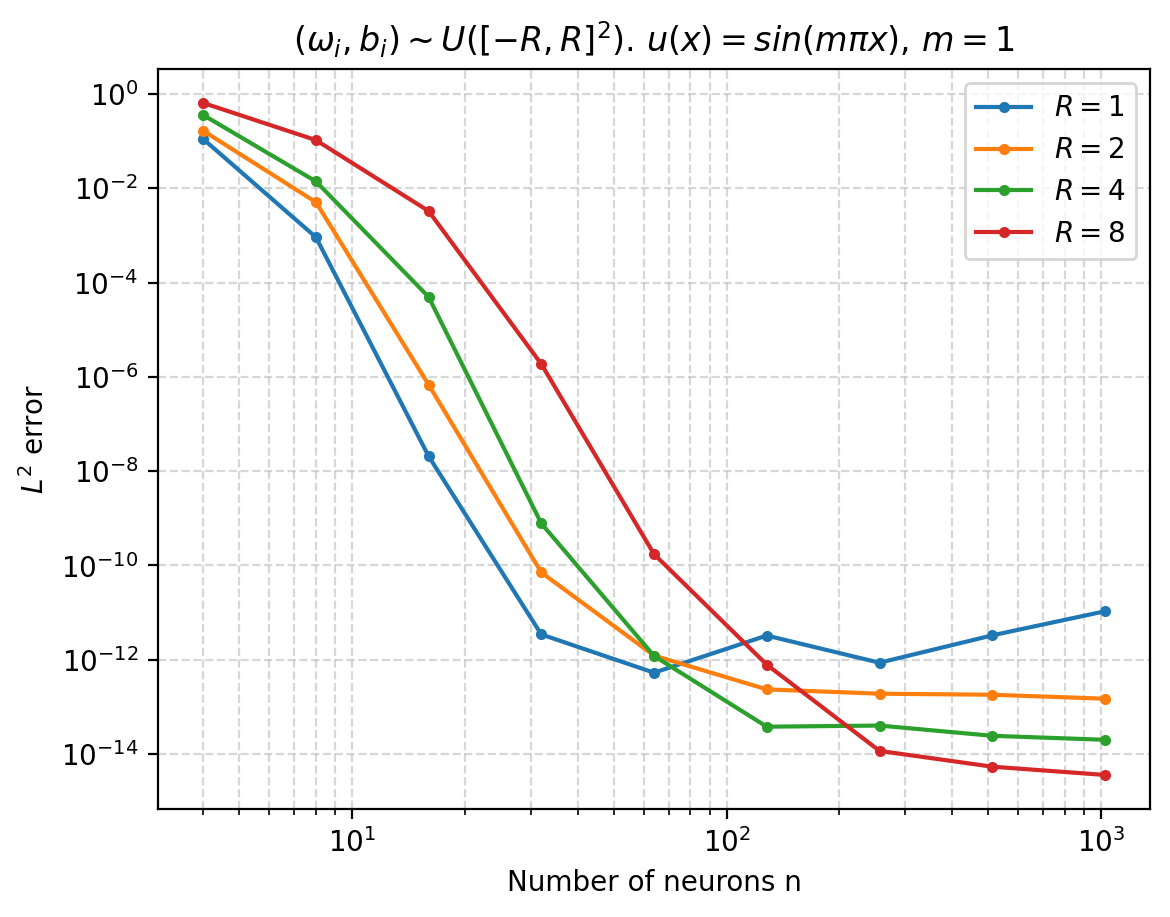

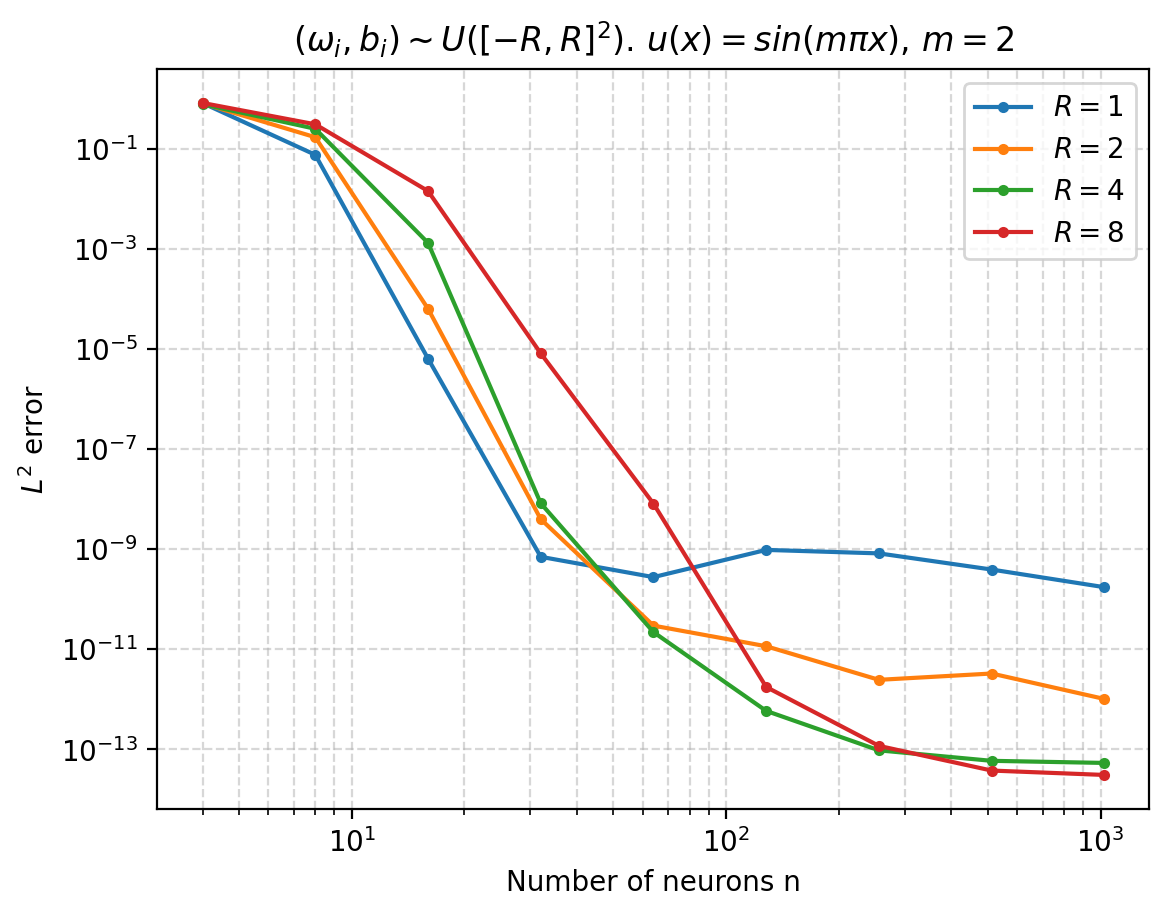

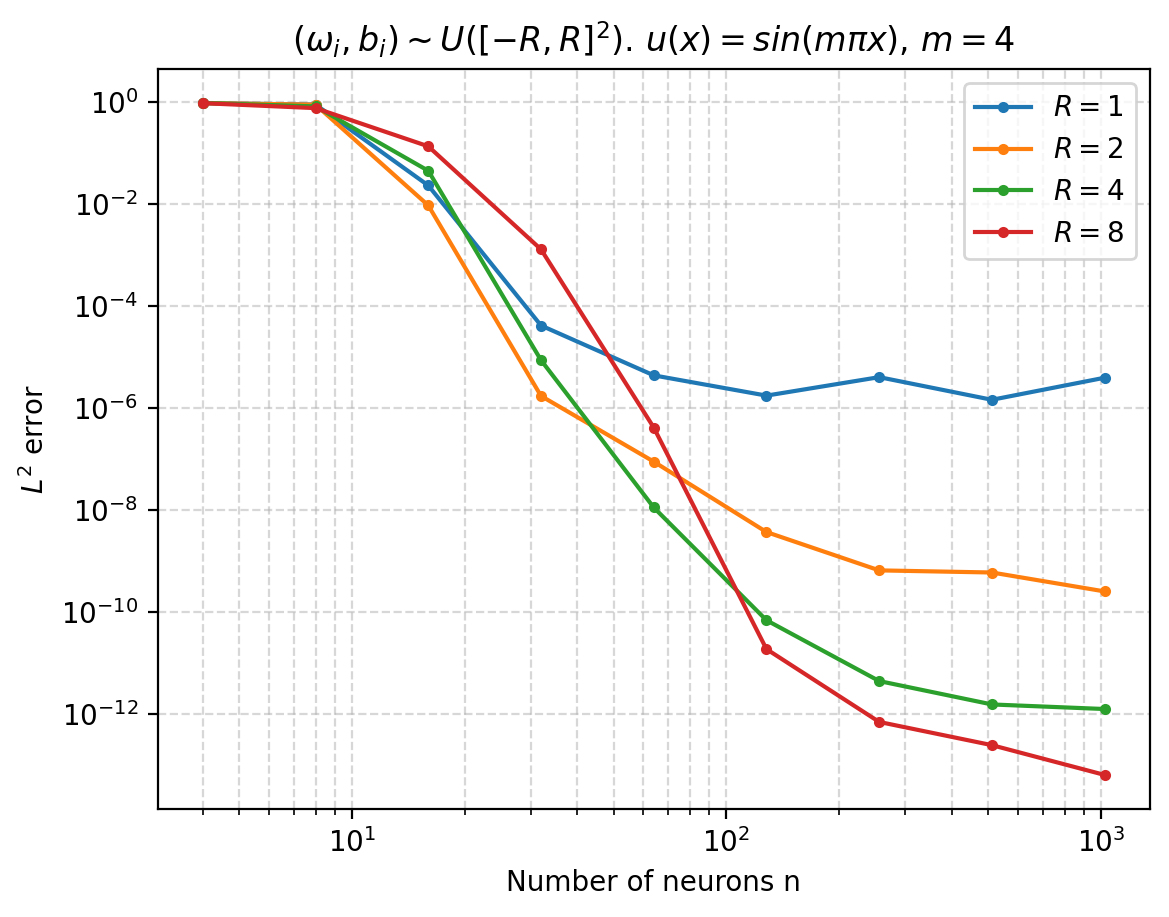

In [9]:
m = 2   
def target(x):
    return torch.sin( m * pi * x)
# plt.rcParams.update({'font.size': 10})
def run_exp_petrushev_1d(target,m): 
    d =1 
    integration_weights, integration_points = PiecewiseGQ1D_weights_points(-1,1,Nx = 1024, order = 5)
    # integration_weights_test, integration_points_test = PiecewiseGQ1D_weights_points(0,1,Nx = 2048, order = 2)
    print("integration_weights shape: ", integration_weights.shape)
    print("integration_points shape: ", integration_points.shape)  

    # collocation points and weights 
    Q = 1024
    collocation_points = torch.linspace(-1,1,Q).view(-1,1)
    collocation_weights = torch.ones(Q).view(-1,1)
    
    save = True 
    petrushev = False 
    R_m_list = [1, 2,4,8]
    
    plt.figure(dpi = 200)
    for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
        mean_err_l2_list = [] 
        neuron_num_arr= np.array([2**i for i in range(2,11)]) 
        for n in neuron_num_arr : 
            trial_num = 5 
            err_l2_trial = torch.zeros(trial_num) 
            for trial in range(trial_num):
                my_model = model_tanh(1, n, 1).to(device) 
                if petrushev: 
                    my_model = initialize_w_b_petrushev(my_model, R_m = R_m)
                else: 
                    my_model = initialize_w_b_uniform(my_model, R_m=R_m) 
                D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,collocation_weights, collocation_points )
                D, b_rhs = rescale_mat_rhs(D,b_rhs)

                sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
                sol =torch.tensor(sol)
                my_model.fc2.weight.data[0,:] = sol.view(-1) 

                with torch.no_grad(): 
                    nn_func_values = my_model(integration_points) 
                target_values = target(integration_points) 

                diff_sqrd = (nn_func_values - target_values)**2 
                err_l2 = ( integration_weights.t() @ diff_sqrd )**0.5 
                err_l2_trial[trial] = err_l2 
            mean_err_l2 = torch.mean(err_l2_trial) 
            mean_err_l2_list.append(mean_err_l2) 
        mean_err_l2_arr = np.array(mean_err_l2_list) 
        # if save: 
        #     data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        #     np.savetxt("ave_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
        legend1 =f"$R = {R_m}$"
        if petrushev: 
            title = f"Petrushev's scheme,$b \in (-R, R)$. $u(x) = sin(m \pi x)$, $m={m}$"
        else: 
            title = f"$(\omega_i,b_i) \sim U([-R,R]^{d+1})$. $u(x) = sin(m \pi x)$, $m={m}$"

        plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
        # plot a reference line and the slope
        plt.yscale('log')
        plt.xscale('log')
        plt.legend()
        plt.ylabel("$L^2$ error")
        plt.xlabel("Number of neurons n")
        plt.title(title)
    
    plt.grid(True, which="both", ls="--", alpha=0.5)
    if petrushev: 
        filename = "data/petrushev_1d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
    else: 
        filename = "data/elm_1d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
    if save:
        plt.savefig(filename)
    else: 
        plt.show()

for m in [1, 2,4]: 
    run_exp_petrushev_1d(target,m)

### sphere initialization

### Monte Carlo data points

## 2D experiments  

In [ ]:
def assemble_least_square_linear_system_quadrature(model,rhs, integration_weights,integration_points): 
    """ Assemble the least square linear system, D: design matrix, b right hand side """
    in_feat, out_feat = model.fc1.weight.shape 
    W = model.fc1.weight.data  # shape: (M, d+1)
    b = model.fc1.bias.data  # shape: (M,)
    Z = integration_points@ W.t() + b  
    D = torch.tanh(Z)  * integration_weights  
    b_rhs = rhs(integration_points) * integration_weights 
    return D,b_rhs


===========> m:  1
===========> m:  2
===========> m:  4


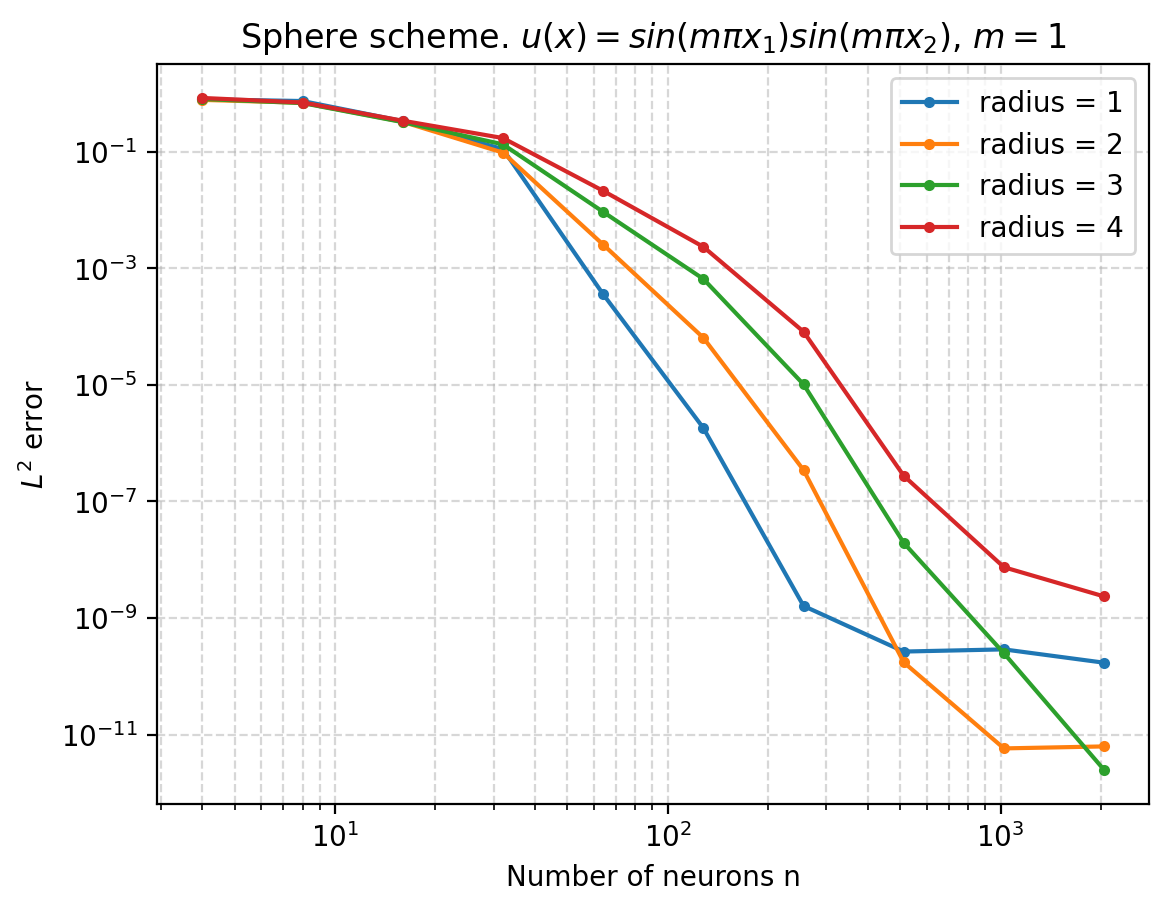

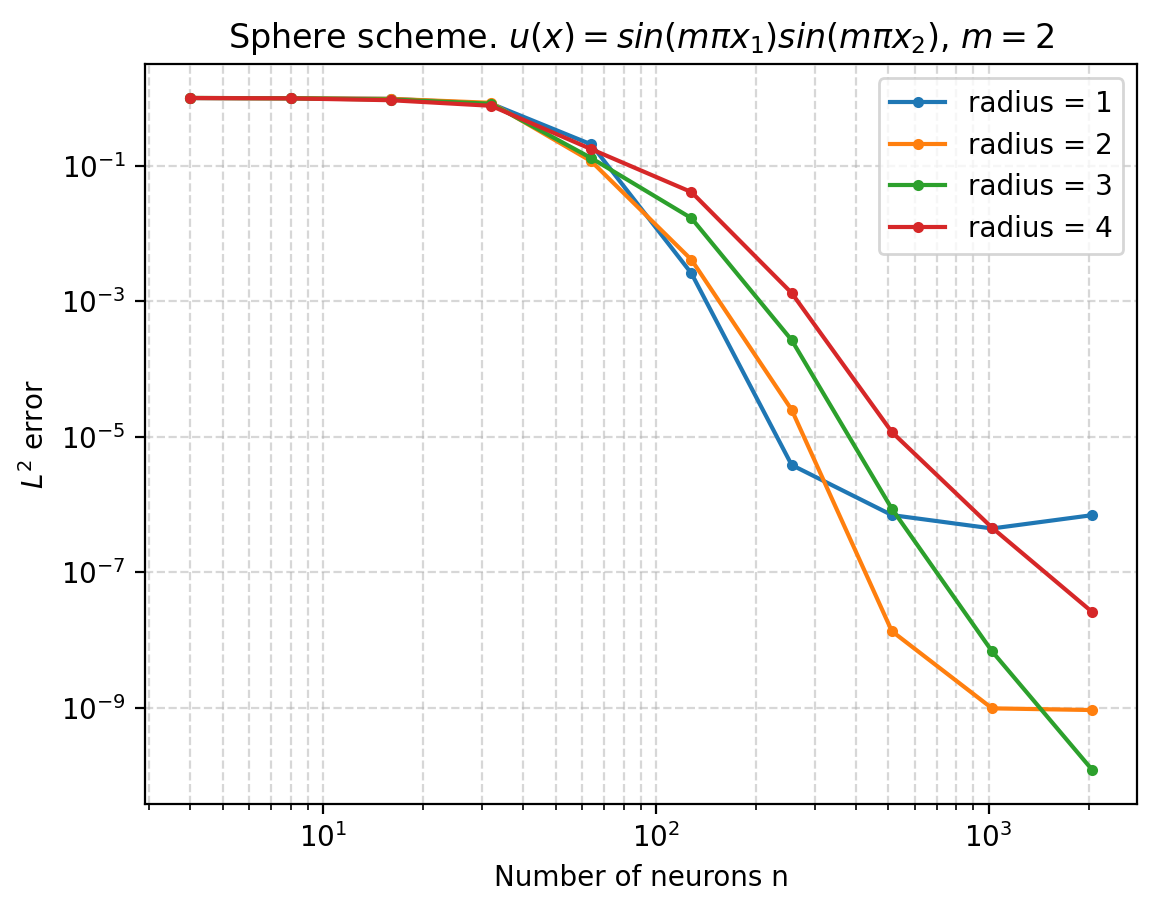

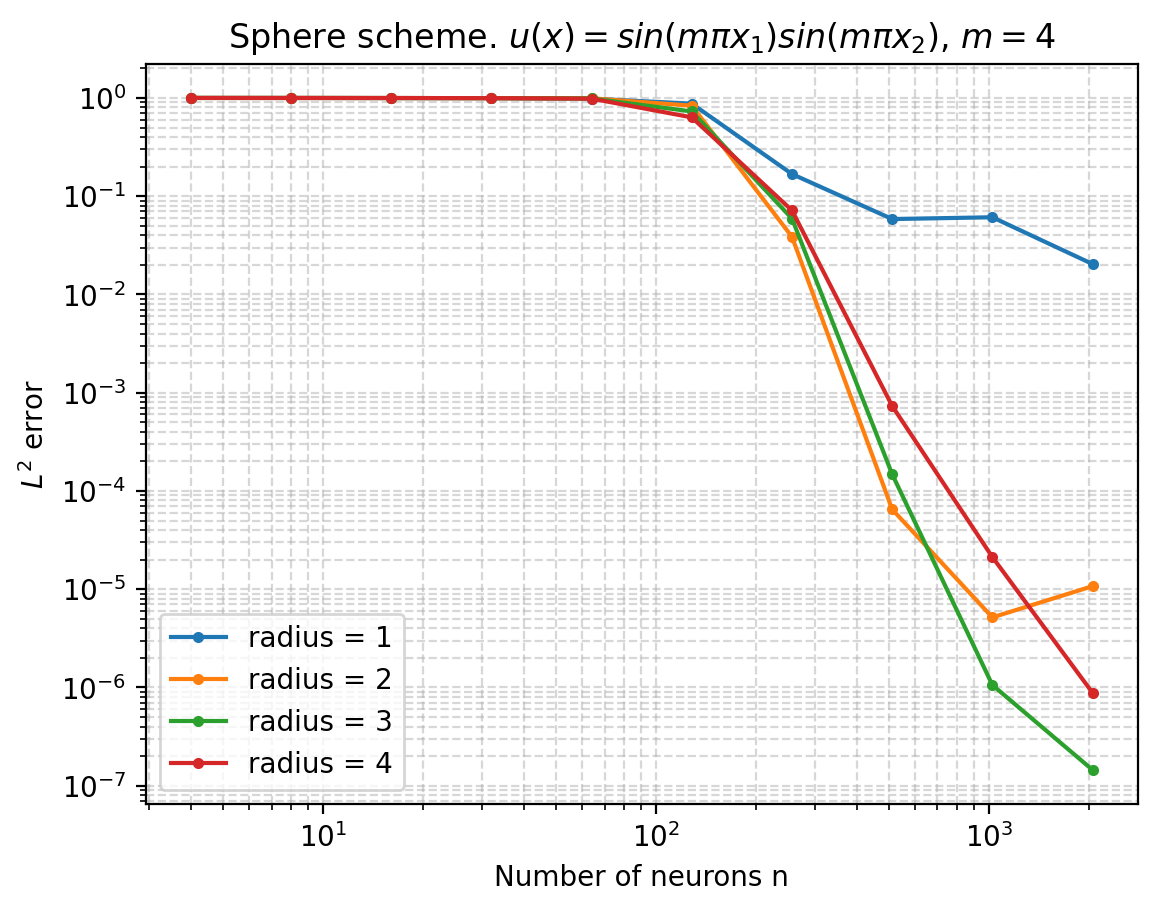

In [ ]:

def run_exp_petrushev_2d(target,m): 
    d = 2 
    Nx = 50  
    order = 3 
    integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
    integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])

    x = torch.linspace(-1,1,50)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
    integration_weights = 1/x_train.size(0)
    integration_points = x_train 
    x = torch.linspace(-1,1,100)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

    save = True  
    petrushev = False 
    elm = False 
    sphere_init = True 

    for radius in [2.5]: 
        R_m_list = [1,2,3,4]
        # fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
        plt.figure(dpi =200)
        for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
            mean_err_l2_list = [] 
            neuron_num_arr= np.array([2**i for i in range(2,12)]) 
            for n in neuron_num_arr : 
                trial_num = 1 
                err_l2_trial = torch.zeros(trial_num) 
                for trial in range(trial_num):
                    my_model = model_tanh(2, n, 1).to(device) 
                    if petrushev: 
                        my_model = initialize_w_b_petrushev(my_model,R_m, scale = 1, radius = radius)
                    if elm: 
                        my_model = initialize_w_b_uniform(my_model,R_m)
                    if sphere_init: 
                        my_model = initialize_w_b_sphere(my_model,R_m) 
                    D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
                    D, b_rhs = rescale_mat_rhs(D,b_rhs)

                    sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
                    sol =torch.tensor(sol)

                    my_model.fc2.weight.data[0,:] = sol.view(-1) 

                    # with torch.no_grad(): 
                    #     nn_func_values = my_model(x_test) 
                    # target_values = target(x_test) 
                    # target_norm = target_values.norm()
                    # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
                    # err_l2_trial[trial] = rel_errl2 

                    with torch.no_grad(): 
                        nn_func_values = my_model(integration_points_test) 
                    target_values = target(integration_points_test) 
                    diff_sqrd = (nn_func_values - target_values)**2 
                    err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
                    err_l2_trial[trial] = err_l2 
                mean_err_l2 = torch.mean(err_l2_trial) 
                mean_err_l2_list.append(mean_err_l2) 
            mean_err_l2_arr = np.array(mean_err_l2_list) 
            # if save: 
            #     data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
            #     np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
        
            legend1 = f"radius = {R_m}" 
            # legend1 =f"$r_1 = {radius}, r_2 = {R_m}$"
            if petrushev: 
                # title = f"Petrushev's scheme,$ b \in (-R, R)$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"
                title = f"Petrushev's scheme. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"
            if elm: 
                title = f"$(\omega_i,b_i) \sim U([-R,R]^{d+1})$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"
            if sphere_init: 
                title = f"Sphere scheme. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"

            plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
            # # plot a reference line and the slope
            # log_M = np.log(neuron_num_arr)
            # log_errors = np.log(mean_err_l2_arr)
            # slope, intercept = np.polyfit(log_M, log_errors, 1)
            # def line_of_best_fit(x):
            #     return np.exp(intercept) * (x ** slope)
            # best_fit = line_of_best_fit(neuron_num_arr)
            # ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)
            plt.yscale('log')
            plt.xscale('log')
            plt.legend()
            plt.ylabel("$L^2$ error")
            plt.xlabel("Number of neurons n")
            plt.title(title) 
        plt.grid(True, which="both", ls="--", alpha=0.5)
        if petrushev: 
            filename = "data/petrushev_2d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
        if elm: 
            filename = "data/elm_2d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
        if sphere_init: 
            filename = "data/sphere_scheme_2d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
        if save: 
            plt.savefig(filename)
        else:
            plt.show() 
def make_target(m):
    def target(x):
        return torch.sin(m * pi* x[:,0:1]) * torch.sin(m * pi * x[:,1:2]) 
    return target

for m in [1,2,4]:
    print("===========> m: ", m)
    run_exp_petrushev_2d(make_target(m), m)

===========> m:  1


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_88698/175566131.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta).to(device)


===========> m:  2
===========> m:  4


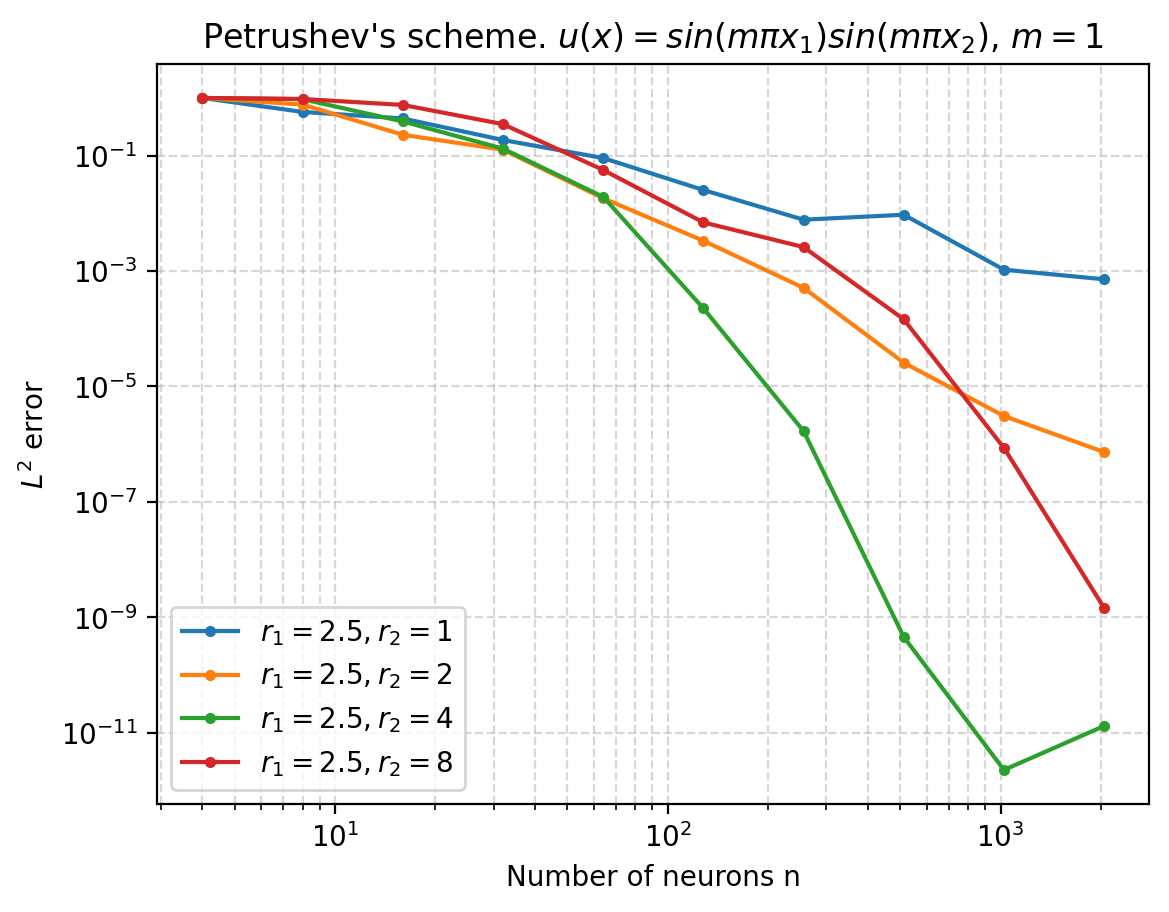

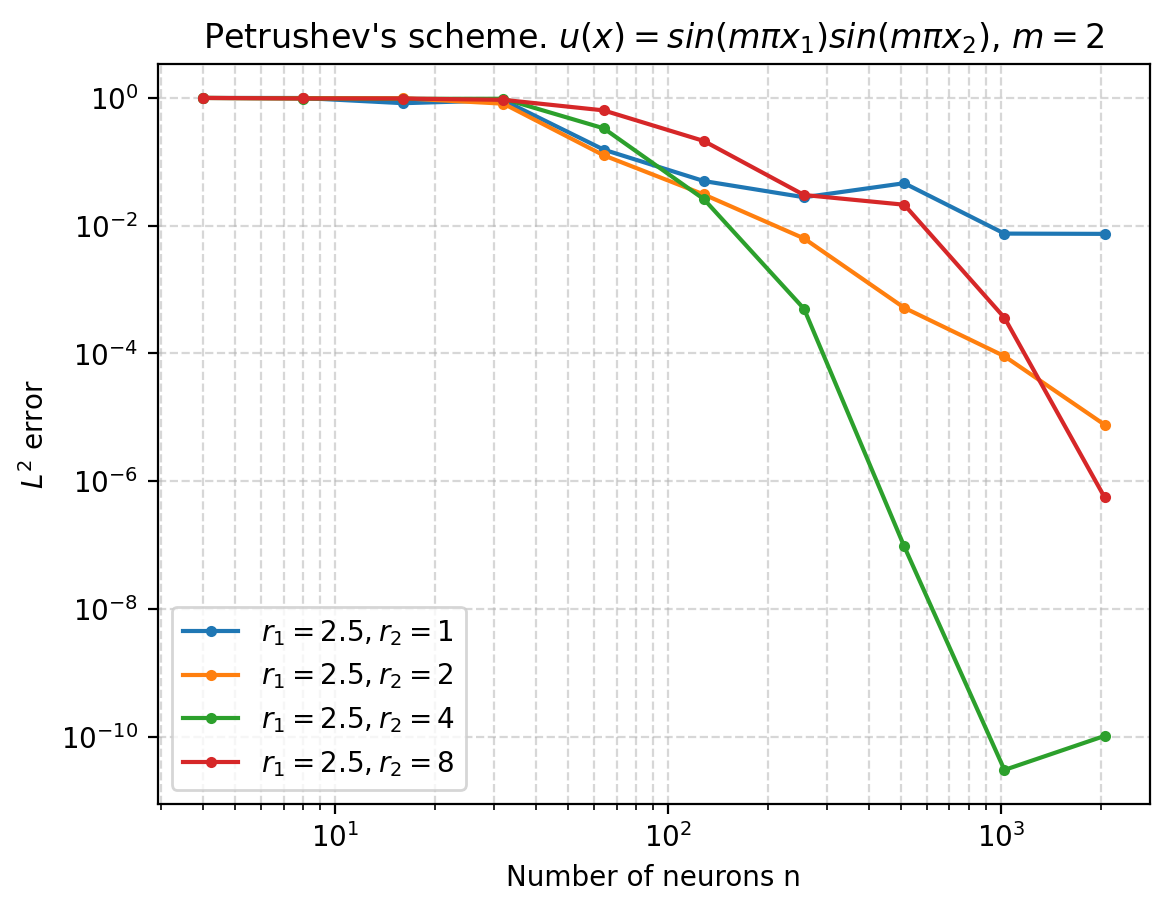

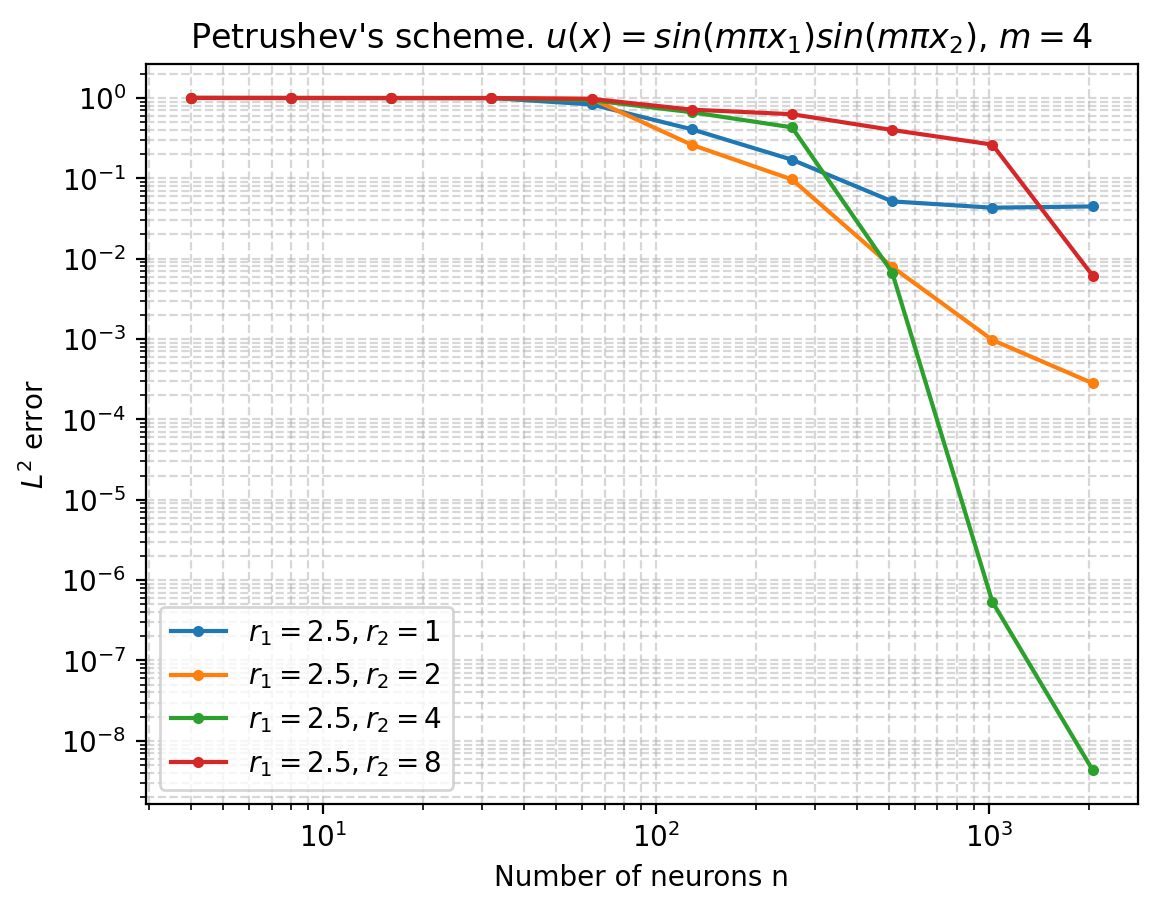

In [ ]:

def run_exp_petrushev_2d(target,m): 
    d = 2 
    Nx = 50  
    order = 3 
    integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
    integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])

    x = torch.linspace(-1,1,50)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
    integration_weights = 1/x_train.size(0)
    integration_points = x_train 
    x = torch.linspace(-1,1,100)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

    save = True 
    petrushev = True 

    for radius in [2.5]: 
        R_m_list = [1,2,4,8]
        # fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
        plt.figure(dpi =200)
        for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
            mean_err_l2_list = [] 
            neuron_num_arr= np.array([2**i for i in range(2,12)]) 
            for n in neuron_num_arr : 
                trial_num = 1 
                err_l2_trial = torch.zeros(trial_num) 
                for trial in range(trial_num):
                    my_model = model_tanh(2, n, 1).to(device) 
                    if petrushev: 
                        my_model = initialize_w_b_petrushev(my_model,R_m, scale = 1, radius = radius)
                    else: 
                        my_model = initialize_w_b_uniform(my_model,R_m)
                    D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
                    D, b_rhs = rescale_mat_rhs(D,b_rhs)

                    sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
                    sol =torch.tensor(sol)

                    my_model.fc2.weight.data[0,:] = sol.view(-1) 

                    # with torch.no_grad(): 
                    #     nn_func_values = my_model(x_test) 
                    # target_values = target(x_test) 
                    # target_norm = target_values.norm()
                    # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
                    # err_l2_trial[trial] = rel_errl2 

                    with torch.no_grad(): 
                        nn_func_values = my_model(integration_points_test) 
                    target_values = target(integration_points_test) 
                    diff_sqrd = (nn_func_values - target_values)**2 
                    err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
                    err_l2_trial[trial] = err_l2 
                mean_err_l2 = torch.mean(err_l2_trial) 
                mean_err_l2_list.append(mean_err_l2) 
            mean_err_l2_arr = np.array(mean_err_l2_list) 
            # if save: 
            #     data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
            #     np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
        
            # legend1 = f"R={R_m}" 
            legend1 =f"$r_1 = {radius}, r_2 = {R_m}$"
            if petrushev: 
                # title = f"Petrushev's scheme,$ b \in (-R, R)$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"
                title = f"Petrushev's scheme. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"
            else: 
                title = f"$(\omega_i,b_i) \sim U([-R,R]^{d+1})$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"

            plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
            # # plot a reference line and the slope
            # log_M = np.log(neuron_num_arr)
            # log_errors = np.log(mean_err_l2_arr)
            # slope, intercept = np.polyfit(log_M, log_errors, 1)
            # def line_of_best_fit(x):
            #     return np.exp(intercept) * (x ** slope)
            # best_fit = line_of_best_fit(neuron_num_arr)
            # ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)
            plt.yscale('log')
            plt.xscale('log')
            plt.legend()
            plt.ylabel("$L^2$ error")
            plt.xlabel("Number of neurons n")
            plt.title(title) 
        plt.grid(True, which="both", ls="--", alpha=0.5)
        if petrushev: 
            filename = "data/petrushev_2d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
        else:
            filename = "data/elm_2d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
        if save: 
            plt.savefig(filename)
        else:
            plt.show() 
def make_target(m):
    def target(x):
        return torch.sin(m * pi* x[:,0:1]) * torch.sin(m * pi * x[:,1:2]) 
    return target

for m in [1,2,4]:
    print("===========> m: ", m)
    run_exp_petrushev_2d(make_target(m), m)

### 2D scheme 1

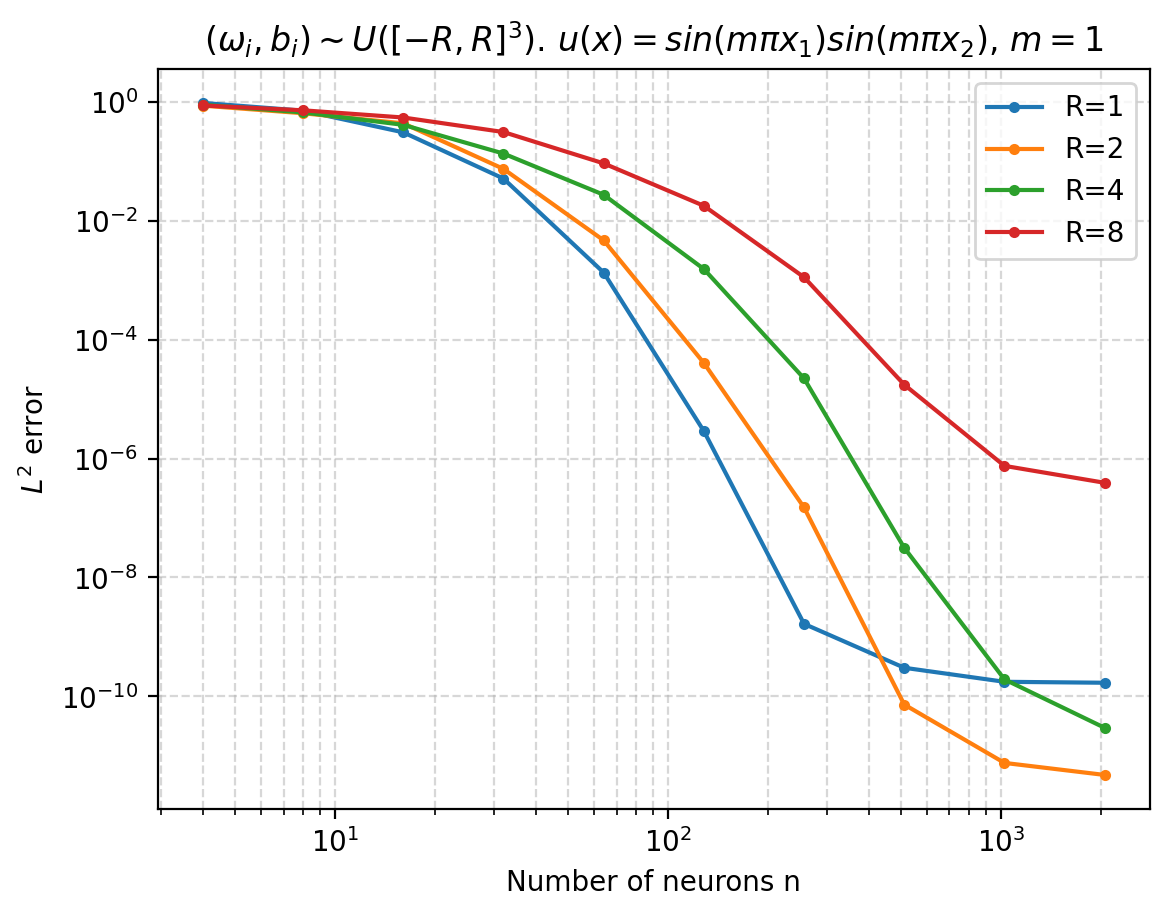

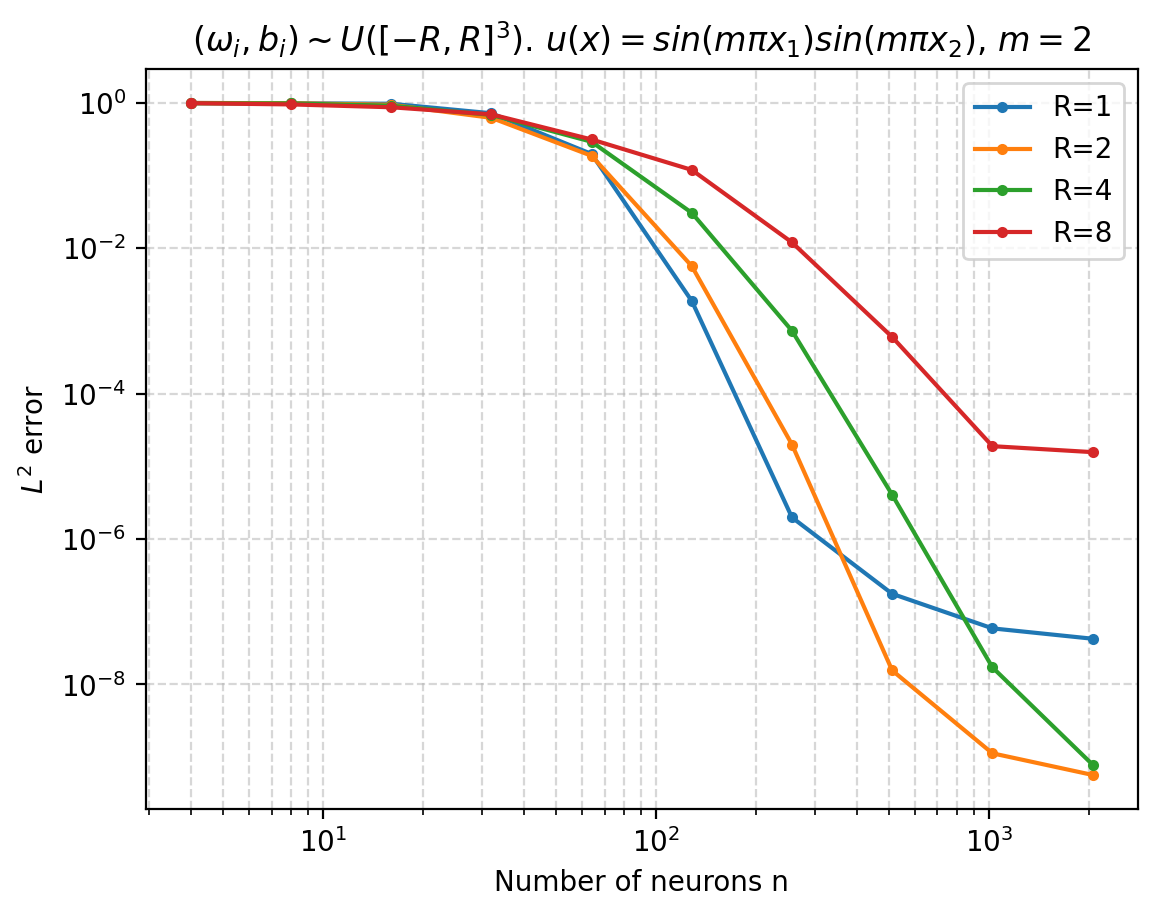

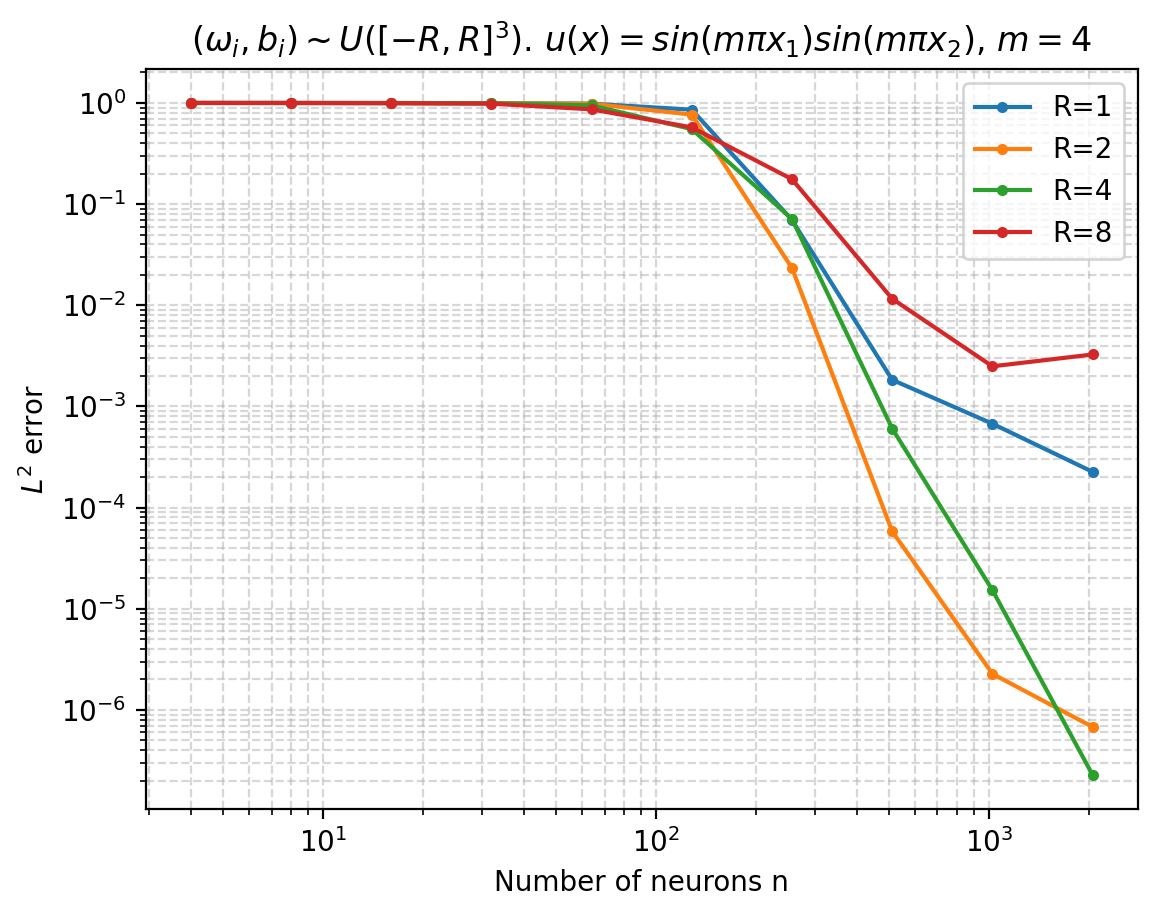

In [13]:
def assemble_least_square_linear_system_quadrature(model,rhs, integration_weights,integration_points): 
    """ Assemble the least square linear system, D: design matrix, b right hand side """
    in_feat, out_feat = model.fc1.weight.shape 
    W = model.fc1.weight.data  # shape: (M, d+1)
    b = model.fc1.bias.data  # shape: (M,)
    Z = integration_points@ W.t() + b  
    D = torch.tanh(Z)  * integration_weights  
    b_rhs = rhs(integration_points) * integration_weights 
    return D,b_rhs

def run_exp_petrushev_2d(target,m): 
    d = 2 
    Nx = 50  
    order = 3 
    integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
    integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])

    x = torch.linspace(-1,1,50)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
    integration_weights = 1/x_train.size(0)
    integration_points = x_train 
    x = torch.linspace(-1,1,100)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

    save = True 
    petrushev = False 

    R_m_list = [1,2,4,8]
    # fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
    plt.figure(dpi =200)
    for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32  
        mean_err_l2_list = [] 
        neuron_num_arr= np.array([2**i for i in range(2,12)]) 
        for n in neuron_num_arr : 
            trial_num = 5
            err_l2_trial = torch.zeros(trial_num) 
            for trial in range(trial_num):
                my_model = model_tanh(2, n, 1).to(device) 
                if petrushev: 
                    my_model = initialize_w_b_petrushev(my_model,R_m, scale = 1)
                else: 
                    my_model = initialize_w_b_uniform(my_model,R_m)
                D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
                D, b_rhs = rescale_mat_rhs(D,b_rhs)

                sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
                sol =torch.tensor(sol)

                my_model.fc2.weight.data[0,:] = sol.view(-1) 

                # with torch.no_grad(): 
                #     nn_func_values = my_model(x_test) 
                # target_values = target(x_test) 
                # target_norm = target_values.norm()
                # rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
                # err_l2_trial[trial] = rel_errl2 

                with torch.no_grad(): 
                    nn_func_values = my_model(integration_points_test) 
                target_values = target(integration_points_test) 
                diff_sqrd = (nn_func_values - target_values)**2 
                err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
                err_l2_trial[trial] = err_l2 
            mean_err_l2 = torch.mean(err_l2_trial) 
            mean_err_l2_list.append(mean_err_l2) 
        mean_err_l2_arr = np.array(mean_err_l2_list) 
        # if save: 
        #     data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        #     np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
    
        legend1 = f"R={R_m}" 
        if petrushev: 
            title = f"Petrushev's scheme,$ b \in (-R, R)$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"
        else: 
            title = f"$(\omega_i,b_i) \sim U([-R,R]^{d+1})$. $u(x) = sin(m \pi x_1)sin(m \pi x_2)$, $m={m}$"

        plt.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1)
        # # plot a reference line and the slope
        # log_M = np.log(neuron_num_arr)
        # log_errors = np.log(mean_err_l2_arr)
        # slope, intercept = np.polyfit(log_M, log_errors, 1)
        # def line_of_best_fit(x):
        #     return np.exp(intercept) * (x ** slope)
        # best_fit = line_of_best_fit(neuron_num_arr)
        # ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)
        plt.yscale('log')
        plt.xscale('log')
        plt.legend()
        plt.ylabel("$L^2$ error")
        plt.xlabel("Number of neurons n")
        plt.title(title) 
    plt.grid(True, which="both", ls="--", alpha=0.5)
    if petrushev: 
        filename = "data/petrushev_2d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
    else:
        filename = "data/elm_2d_sin_m_{}_collocation_R_m_{}.png".format(m,R_m)
    if save: 
        plt.savefig(filename)
    else:
        plt.show() 
def make_target(m):
    def target(x):
        return torch.sin(m * pi* x[:,0:1]) * torch.sin(m * pi * x[:,1:2]) 
    return target

for m in [1,2,4]:
    run_exp_petrushev_2d(make_target(m), m)

## 3D experiments 

### 3D scheme 1 
Incomplete!!! Sept 9th 
Need further tests!! 


In [8]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
def u_exact(x): 
    z = torch.sin(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3])  
    return z 
def u_x(x):
    z = (pi/2)*torch.cos(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3])  
    return z
def u_y(x):
    z = (pi/2)*torch.sin(pi/2*x[:,0:1])*torch.cos(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3])  
    return z 
def u_z(x):
    z = (pi/2)*torch.sin(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.cos(pi/2*x[:,2:3])  
    return z 
def target(x):
    z = (3 * (pi/2)**2 + 1)*torch.sin(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3]) 
    return z
def u_exact_grad(): 
    return [u_x, u_y, u_z]
 
Nx = 25   
order = 3 
integration_weights, integration_points = PiecewiseGQ3D_weights_points(Nx, order,[0,0,0],[1,1,1])

integration_weights_test, integration_points_test =  PiecewiseGQ3D_weights_points(30, order,[0,0,0],[1,1,1])

save = False 
R_m_list = [1,2,4]
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32 
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,11)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 5 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(3, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_petrushev(my_model,R_m, scale = 1) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            # sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct",activation='tanh')
            # my_model.fc2.weight.data[0,:] = sol[:]

            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs) 
            # print("shape of D: ", D.shape)
            # print("shape of b_rhs: ", b_rhs.shape) 
            sol =  torch.linalg.lstsq(D,b_rhs).solution # driver='gelsd'
            # print("sol shape: ", sol.shape) 
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            
            with torch.no_grad(): 
                nn_func_values = my_model(integration_points_test) 
            target_values = target(integration_points_test) 

            diff_sqrd = (nn_func_values - target_values)**2 
            err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
    
    legend1 = "Scheme 1: $(\omega_i,b_i) \sim U(-{}, {})$".format(R_m,R_m)
    title = "Scheme 1: $U(-{}, {})$".format(R_m,R_m) 
    # plt.figure(dpi = 400)
    ax = axes[ind]
    ax.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    # plot a reference line and the slope
    log_M = np.log(neuron_num_arr)
    log_errors = np.log(mean_err_l2_arr)
    slope, intercept = np.polyfit(log_M, log_errors, 1)
    def line_of_best_fit(x):
        return np.exp(intercept) * (x ** slope)
    best_fit = line_of_best_fit(neuron_num_arr)
    ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)

    
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.legend()
    ax.set_ylabel("$L^2$ error")
    ax.set_xlabel("Number of neurons n")
    ax.set_title(title) 

plt.tight_layout()
plt.show()

In [ ]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
def u_exact(x): 
    z = torch.sin(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3])  
    return z 
def u_x(x):
    z = (pi/2)*torch.cos(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3])  
    return z
def u_y(x):
    z = (pi/2)*torch.sin(pi/2*x[:,0:1])*torch.cos(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3])  
    return z 
def u_z(x):
    z = (pi/2)*torch.sin(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.cos(pi/2*x[:,2:3])  
    return z 
def target(x):
    z = (3 * (pi/2)**2 + 1)*torch.sin(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3]) 
    return z
def u_exact_grad(): 
    return [u_x, u_y, u_z]
 
Nx = 25   
order = 3 
integration_weights, integration_points = PiecewiseGQ3D_weights_points(Nx, order,[-1,-1,-1],[1,1,1])

integration_weights_test, integration_points_test =  PiecewiseGQ3D_weights_points(30, order,[-1,-1,-1],[1,1,1])

save = False 
R_m_list = [0.5,1,2]
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32 
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,11)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 5 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(3, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_uniform(my_model,R_m) 
            # sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct",activation='tanh')
            # my_model.fc2.weight.data[0,:] = sol[:]

            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            # print("shape of D: ", D.shape)
            # print("shape of b_rhs: ", b_rhs.shape) 
            sol =  torch.linalg.lstsq(D,b_rhs).solution # driver='gelsd'
            # print("sol shape: ", sol.shape) 
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            
            
            with torch.no_grad(): 
                nn_func_values = my_model(integration_points_test) 
            target_values = target(integration_points_test) 

            diff_sqrd = (nn_func_values - target_values)**2 
            err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
  
    legend1 = "Scheme 2: $(\omega_i,b_i) \sim U(-{}, {})$".format(R_m,R_m)
    title = "Scheme 2: $U(-{}, {})$".format(R_m,R_m) 
    # plt.figure(dpi = 400)
    ax = axes[ind]
    ax.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    # plot a reference line and the slope
    log_M = np.log(neuron_num_arr)
    log_errors = np.log(mean_err_l2_arr)
    slope, intercept = np.polyfit(log_M, log_errors, 1)
    def line_of_best_fit(x):
        return np.exp(intercept) * (x ** slope)
    best_fit = line_of_best_fit(neuron_num_arr)
    ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.legend()
    ax.set_ylabel("$L^2$ error")
    ax.set_xlabel("Number of neurons n")
    ax.set_title(title) 

plt.tight_layout()
plt.show()

### 3D scheme 3 

In [ ]:

def target(x):
    z = torch.sin(pi/2*x[:,0:1]) * torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3]) 
    return z
 
Nx = 20 
order = 3 
integration_weights, integration_points = PiecewiseGQ3D_weights_points(Nx, order,[-1,-1,-1],[1,1,1])

integration_weights_test, integration_points_test =  PiecewiseGQ3D_weights_points(30, order,[-1,-1,-1],[1,1,1])

save = False 
R_m_list = [1,2,4]
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32 
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,11)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 5 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(3, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            my_model = initialize_w_b_petrushev(my_model,R_m) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            # sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct",activation='tanh')
            # my_model.fc2.weight.data[0,:] = sol[:]

            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            # print("shape of D: ", D.shape)
            # print("shape of b_rhs: ", b_rhs.shape) 
            sol =  torch.linalg.lstsq(D,b_rhs).solution # driver='gelsd'
            # print("sol shape: ", sol.shape) 
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            
            with torch.no_grad(): 
                nn_func_values = my_model(integration_points_test) 
            target_values = target(integration_points_test) 

            diff_sqrd = (nn_func_values - target_values)**2 
            err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
    
    legend1 = "Scheme 3: Petrushev. R = {}".format(R_m)
    title = "Scheme 3: Petrushev R = {}".format(R_m) 
    # plt.figure(dpi = 400)
    ax = axes[ind]
    ax.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    # plot a reference line and the slope
    log_M = np.log(neuron_num_arr)
    log_errors = np.log(mean_err_l2_arr)
    slope, intercept = np.polyfit(log_M, log_errors, 1)
    def line_of_best_fit(x):
        return np.exp(intercept) * (x ** slope)
    best_fit = line_of_best_fit(neuron_num_arr)
    ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)

    
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.legend()
    ax.set_ylabel("$L^2$ error")
    ax.set_xlabel("Number of neurons n")
    ax.set_title(title) 

plt.tight_layout()
plt.show()

/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_23441/480780926.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  biases = torch.tensor(biases).to(device)


In [ ]:
### 

### 3D scheme 4 

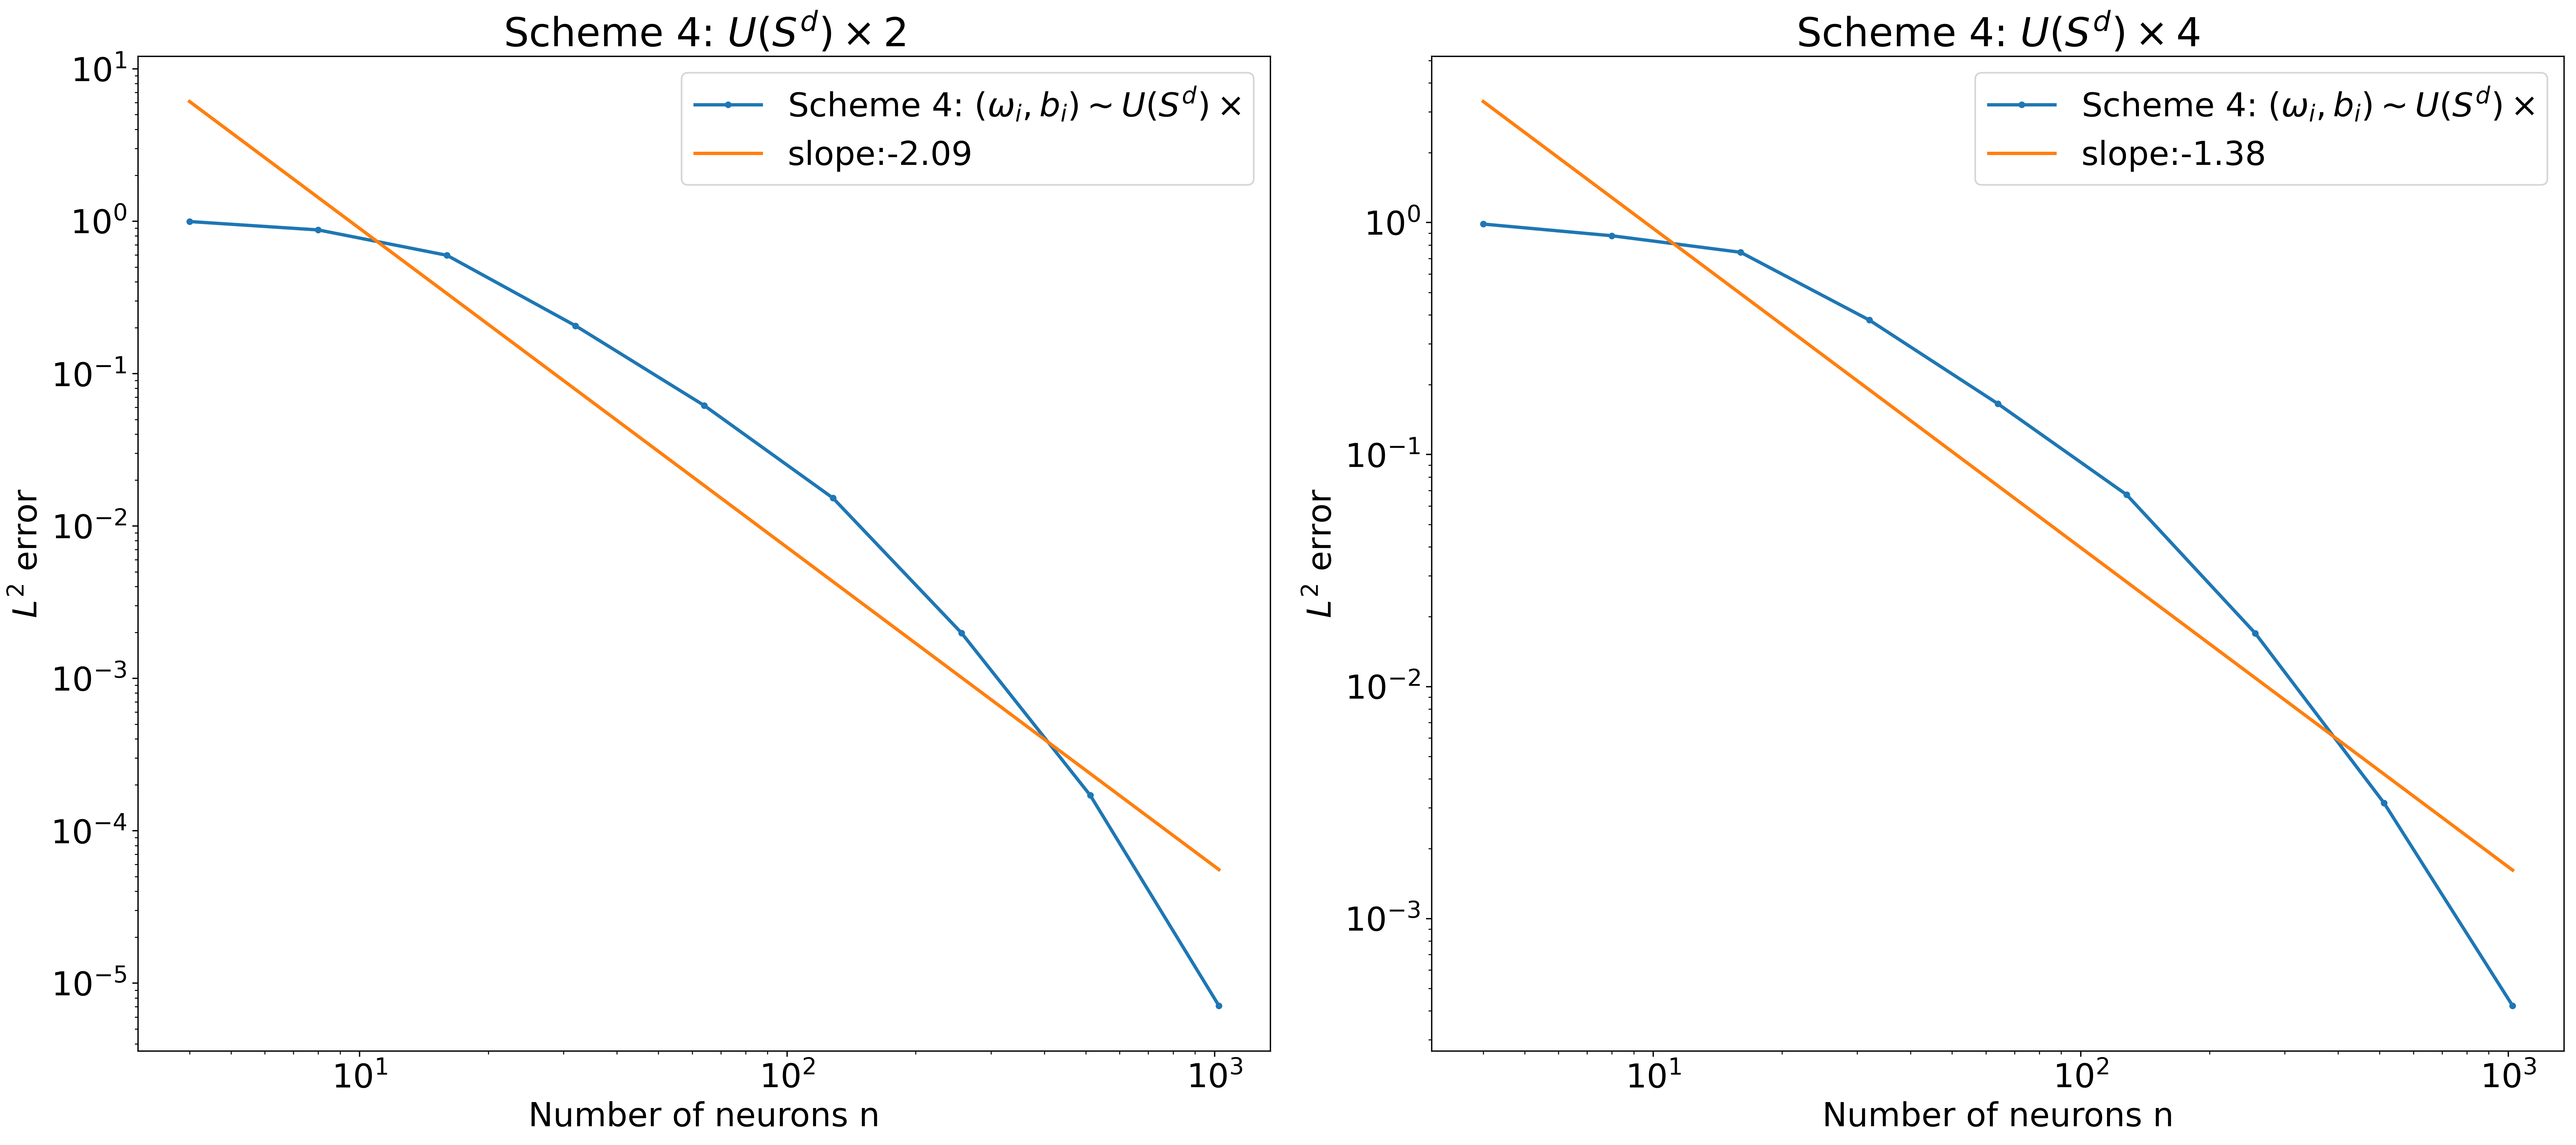

In [47]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
def target(x):
    z = torch.sin(pi/2*x[:,0:1])*torch.sin(pi/2*x[:,1:2] ) * torch.sin(pi/2*x[:,2:3]) 
    return z
def u_exact_grad(): 
    return [u_x, u_y, u_z]
 
Nx = 20 
order = 3 
integration_weights, integration_points = PiecewiseGQ3D_weights_points(Nx, order,[-1,-1,-1],[1,1,1])

integration_weights_test, integration_points_test =  PiecewiseGQ3D_weights_points(30, order,[-1,-1,-1],[1,1,1])

save = False 
R_m_list = [2,4]
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, len(R_m_list), figsize=(11*len(R_m_list), 10), dpi=400)
for ind, R_m in enumerate(R_m_list): #  1,2,4,8,16,32 
    mean_err_l2_list = [] 
    neuron_num_arr= np.array([2**i for i in range(2,11)]) 
    # neuron_num_arr= np.array([i for i in range(1,200,20)]) 
    for n in neuron_num_arr : 
        trial_num = 5 
        err_l2_trial = torch.zeros(trial_num) 
        for trial in range(trial_num):
            my_model = model_tanh(3, n, 1).to(device) 
            # my_model = initialize_w_sphere_b_uniform(my_model,R_m) 
            # my_model = initialize_w_b_petrushev(my_model,R_m) 
            my_model = initialize_w_b_sphere(my_model,R_m) 
            # my_model = initialize_w_b_uniform(my_model,R_m) 
            # sol = minimize_linear_layer_explicit_assemble(my_model,target,weights, integration_points, solver="direct",activation='tanh')
            # my_model.fc2.weight.data[0,:] = sol[:]

            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)

            # sol =  torch.linalg.lstsq(D,b_rhs).solution # ,driver='gelsd'
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)
            my_model.fc2.weight.data[0,:] = sol.view(-1) 
            
            with torch.no_grad(): 
                nn_func_values = my_model(integration_points_test) 
            target_values = target(integration_points_test) 

            diff_sqrd = (nn_func_values - target_values)**2 
            err_l2 = ( integration_weights_test.t() @ diff_sqrd )**0.5 
            err_l2_trial[trial] = err_l2 
        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 
    mean_err_l2_arr = np.array(mean_err_l2_list) 
    if save: 
        data_uniform_distribution = np.concatenate([neuron_num_arr.reshape(-1,1),mean_err_l2_arr.reshape(-1,1)],axis = 1) 
        np.savetxt("2d_save_l2err_uniform_distribution_Rm_{}_trials_{}.txt".format(R_m, trial_num),data_uniform_distribution)
    
    legend1 = "Scheme 4: $(\omega_i,b_i) \sim U(S^d) \\times $".format(R_m)
    title = "Scheme 4: $U(S^d) \\times {}$".format(R_m) 
    # plt.figure(dpi = 400)
    ax = axes[ind]
    ax.plot(neuron_num_arr, mean_err_l2_arr, '.-', label = legend1, linewidth = 2)
    # plot a reference line and the slope
    log_M = np.log(neuron_num_arr)
    log_errors = np.log(mean_err_l2_arr)
    slope, intercept = np.polyfit(log_M, log_errors, 1)
    def line_of_best_fit(x):
        return np.exp(intercept) * (x ** slope)
    best_fit = line_of_best_fit(neuron_num_arr)
    ax.plot(neuron_num_arr, best_fit, label = "slope:{}".format(round(slope,2) ), linewidth = 2)

    
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.legend()
    ax.set_ylabel("$L^2$ error")
    ax.set_xlabel("Number of neurons n")
    ax.set_title(title) 

plt.tight_layout()
plt.show()